# Concept Activation Vectors (CAVs) on Clash of Clans bases

Model: **ResNet50** with `layer4` + final FC fine-tuned on **Town Hall classification** (8 classes, TH10–TH17).

Two CAVs (auto-labeled from filenames):
- **Scenery CAV** — `farm` / `defence` bases (vegetation surroundings + decorations) vs. `war` bases (red volcanic terrain) sampled from TH15–17 only.
- **TH12 CAV** — TH12 bases (distinctive blue theme) vs. balanced sample of other TH levels.

TO RUN MORE: Go -https://clashofclans-layouts.com/ and pick a base then a new cell calling analyze('path/to/image')

In [1]:
import os, glob, random
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import transforms, datasets, models
from torchvision.models import ResNet50_Weights
from PIL import Image
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
DATA_DIR = Path('/Users/alexandergarcia/Documents/nerd/CNN-Clash/scrape')
MODEL_PATH = Path('models/coc_resnet50.pt')
MODEL_PATH.parent.mkdir(exist_ok=True)
SEED = 0
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)

if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'
print('device:', DEVICE)

weights = ResNet50_Weights.IMAGENET1K_V2
preprocess = weights.transforms()

device: mps


In [3]:
class_names = [f'th_{i}' for i in range(10, 18)]
n_classes = len(class_names)
class_to_idx = {c: i for i, c in enumerate(class_names)}

class CoCDataset(torch.utils.data.Dataset):
    def __init__(self, root, classes, transform):
        self.transform = transform
        self.samples = [
            (p, class_to_idx[c])
            for c in classes
            for p in sorted(glob.glob(str(Path(root) / c / '*.jpg')))
        ]
    def __len__(self): return len(self.samples)
    def __getitem__(self, i):
        p, y = self.samples[i]
        return self.transform(Image.open(p).convert('RGB')), y

full_dataset = CoCDataset(DATA_DIR, class_names, preprocess)
n = len(full_dataset)
n_val = int(0.2 * n)
train_set, val_set = random_split(
    full_dataset, [n - n_val, n_val],
    generator=torch.Generator().manual_seed(SEED),
)
train_loader = DataLoader(train_set, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_set, batch_size=32, shuffle=False, num_workers=0)
print(f'classes: {class_names}')
print(f'train: {len(train_set)}  val: {len(val_set)}')

classes: ['th_10', 'th_11', 'th_12', 'th_13', 'th_14', 'th_15', 'th_16', 'th_17']
train: 834  val: 208


In [4]:
def build_model():
    m = models.resnet50(weights=weights)
    for p in m.parameters():
        p.requires_grad = False
    for p in m.layer4.parameters():
        p.requires_grad = True
    m.fc = nn.Linear(m.fc.in_features, n_classes)
    return m

model = build_model().to(DEVICE)

In [5]:
if MODEL_PATH.exists():
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    print('loaded cached weights')
else:
    optimizer = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=1e-4)
    loss_fn = nn.CrossEntropyLoss()
    EPOCHS = 5
    for epoch in range(EPOCHS):
        model.train()
        running = 0.0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            loss = loss_fn(model(x), y)
            loss.backward()
            optimizer.step()
            running += loss.item() * x.size(0)
        model.eval()
        correct = total = 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                correct += (model(x).argmax(1) == y).sum().item()
                total += y.size(0)
        print(f'epoch {epoch+1}: train_loss={running/len(train_set):.4f}  val_acc={correct/total:.4f}')
    torch.save(model.state_dict(), MODEL_PATH)
    print(f'saved to {MODEL_PATH}')

loaded cached weights


In [6]:
_activation = {}
def _hook(module, inp, out):
    _activation['layer3'] = out.detach()
model.layer3.register_forward_hook(_hook)

def get_features(image_paths, batch_size=16):
    model.eval()
    feats = []
    with torch.no_grad():
        for i in range(0, len(image_paths), batch_size):
            batch = image_paths[i:i+batch_size]
            imgs = torch.stack([preprocess(Image.open(p).convert('RGB')) for p in batch]).to(DEVICE)
            _ = model(imgs)
            a = _activation['layer3'].mean(dim=(2, 3))
            feats.append(a.cpu().numpy())
    return np.vstack(feats)

In [7]:
all_paths = [Path(p) for c in class_names for p in glob.glob(str(DATA_DIR / c / '*.jpg'))]
rng = random.Random(SEED)

scenery_pos = [p for p in all_paths if ('_farm_' in p.name) or ('_defence_' in p.name)]
high_th_war = [p for p in all_paths if '_war_' in p.name and p.parent.name in {'th_15','th_16','th_17'}]
rng.shuffle(high_th_war)
scenery_neg = high_th_war[:len(scenery_pos)]

th12_pos = [p for p in all_paths if p.parent.name == 'th_12']
others = [p for p in all_paths if p.parent.name != 'th_12']
rng.shuffle(others)
th12_neg = others[:len(th12_pos)]

print(f'scenery: {len(scenery_pos)} pos / {len(scenery_neg)} neg')
print(f'th12:    {len(th12_pos)} pos / {len(th12_neg)} neg')

scenery: 118 pos / 118 neg
th12:    130 pos / 130 neg


In [ ]:
def train_cav(positives, negatives):
    pos_f = get_features([str(p) for p in positives])
    neg_f = get_features([str(p) for p in negatives])
    X = np.vstack([pos_f, neg_f])
    y = np.array([1] * len(pos_f) + [0] * len(neg_f))
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)
    clf = LogisticRegression(max_iter=5000).fit(X_tr, y_tr)
    cav = clf.coef_[0]
    cav = cav / np.linalg.norm(cav)
    return cav, clf.score(X_te, y_te)

cav_scenery, acc_s = train_cav(scenery_pos, scenery_neg)
cav_th12,    acc_t = train_cav(th12_pos,    th12_neg)

scenery CAV held-out acc: 1.000
th12 CAV    held-out acc: 1.000


In [9]:
def analyze(image_path):
    img = Image.open(image_path).convert('RGB')
    x = preprocess(img).unsqueeze(0).to(DEVICE)
    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(x), dim=1).cpu().numpy()[0]
    pred_idx = int(probs.argmax())
    pred_class = class_names[pred_idx]
    pred_prob = float(probs[pred_idx])

    feat = _activation['layer3'].mean(dim=(2, 3)).cpu().numpy()[0]
    feat_unit = feat / (np.linalg.norm(feat) + 1e-9)
    score_scenery = float(np.dot(feat_unit, cav_scenery))
    score_th12 = float(np.dot(feat_unit, cav_th12))

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.imshow(img); ax.axis('off')
    ax.set_title(
        f'prediction: {pred_class} ({pred_prob:.1%})\n'
        f'scenery CAV: {score_scenery:+.3f}    th12 CAV: {score_th12:+.3f}'
    )
    plt.show()
    return {
        'prediction': pred_class,
        'prob': pred_prob,
        'scenery_score': score_scenery,
        'th12_score': score_th12,
    }


=== th12_war_19.jpg (true class: th_12) ===


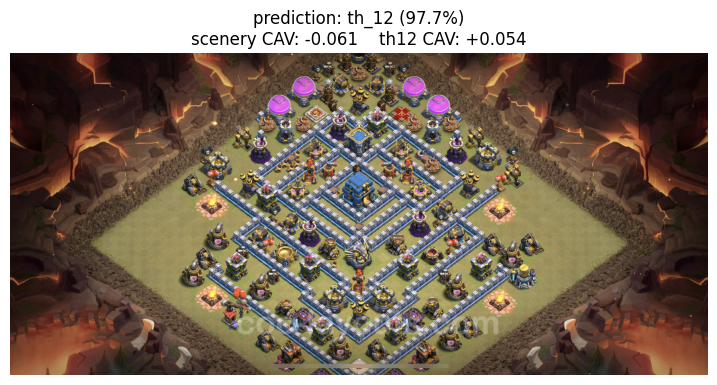

{'prediction': 'th_12', 'prob': 0.9768051505088806, 'scenery_score': -0.06124479713993444, 'th12_score': 0.053855470327185226}

=== th15_farm_5.jpg (true class: th_15) ===


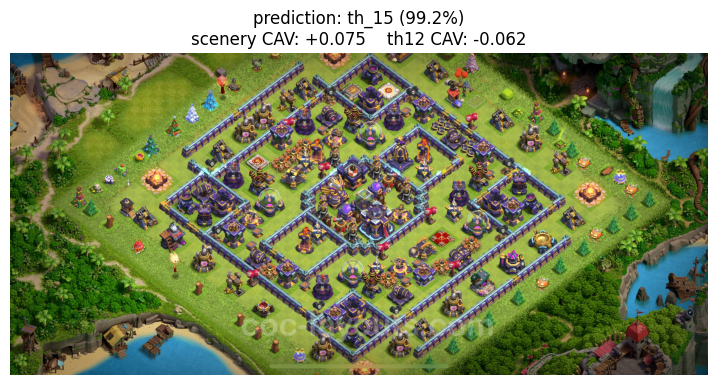

{'prediction': 'th_15', 'prob': 0.9918603301048279, 'scenery_score': 0.07543337313218335, 'th12_score': -0.061897072105227}

=== th10_war_25.jpg (true class: th_10) ===


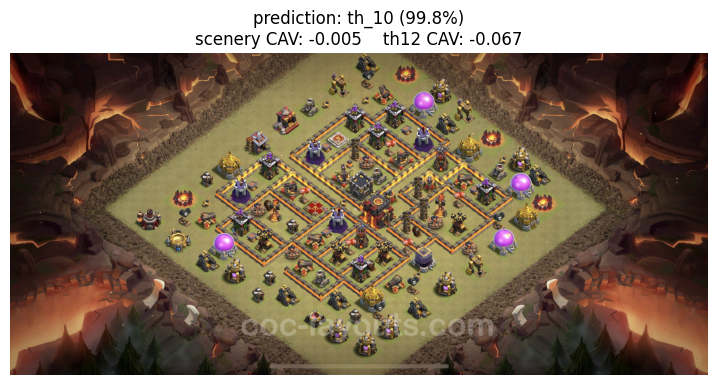

{'prediction': 'th_10', 'prob': 0.9980606436729431, 'scenery_score': -0.004631152912162895, 'th12_score': -0.06727483640876061}


In [10]:
demo_rng = random.Random(42)
demos = [
    demo_rng.choice([p for p in all_paths if '_war_' in p.name and p.parent.name == 'th_12']),
    demo_rng.choice([p for p in all_paths if '_farm_' in p.name]),
    demo_rng.choice([p for p in all_paths if '_war_' in p.name and p.parent.name == 'th_10']),
]
for p in demos:
    print(f'\n=== {p.name} (true class: {p.parent.name}) ===')
    result = analyze(str(p))
    print(result)